# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print("kích thước của dữ liệu:", df.shape)
print()
print("tên các cột:", df.columns)
print()
print("thông tin dữ liệu:", df.info())

kích thước của dữ liệu: (1338, 7)

tên các cột: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
thông tin dữ liệu: None


## A.2. Missing values & Duplicate data

In [4]:
# TODO
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values[missing_values>0] if missing_values.sum()>0 else "Không có cột nào thiếu dữ liệu.")
print()
print("tổng số dòng bị trùng lặp hoàn toàn:", df.duplicated().sum())

Missing values:
Không có cột nào thiếu dữ liệu.

tổng số dòng bị trùng lặp hoàn toàn: 1


## A.3. Invalid values

In [6]:
# TODO
print('age <= 0:', (df['age'] <= 0).sum())
print('bmi <= 0:', (df['bmi'] <= 0).sum())
print('children < 0:', (df['children'] < 0).sum())
print('charges <= 0:', (df['charges'] <= 0).sum())
print("\nCác giá trị trong cột sex:", df['sex'].unique())
print("Các giá trị trong cột smoker:", df['smoker'].unique())
print("Các giá trị trong cột region:", df['region'].unique())
print()
print("=> Dữ liệu sạch và không có giá trị bất thường.")

age <= 0: 0
bmi <= 0: 0
children < 0: 0
charges <= 0: 0

Các giá trị trong cột sex: <StringArray>
['female', 'male']
Length: 2, dtype: str
Các giá trị trong cột smoker: <StringArray>
['yes', 'no']
Length: 2, dtype: str
Các giá trị trong cột region: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

=> Dữ liệu sạch và không có giá trị bất thường.


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [8]:
# TODO
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 25, 30, np.inf], labels=['Normal', 'Overweight', 'Obese'], right=False)
df[['bmi', 'bmi_group']].head()

,bmi,bmi_group
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [12]:
# TODO
for col in ['age', 'bmi', 'charges']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: mean={mean_:.2f}, median={median_:.2f}, mode={mode_:.2f}")
print()
print("Mode Region:", df['region'].mode()[0])
print("Mode bmi_group:", df['bmi_group'].mode()[0])

age: mean=39.21, median=39.00, mode=18.00
bmi: mean=30.66, median=30.40, mode=32.30
charges: mean=13270.42, median=9382.03, mode=1639.56

Mode Region: southeast
Mode bmi_group: Obese


## Group 2 — Dispersion

In [13]:
# TODO
for col in ['age', 'bmi', 'charges']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- age ---
Range=46.00, Std=14.05, IQR=24.00, CV=0.36
--- bmi ---
Range=37.17, Std=6.10, IQR=8.40, CV=0.20
--- charges ---
Range=62648.55, Std=12110.01, IQR=11899.63, CV=0.91


## Group 3 — Location and Shape

--- age ---
P25=27.00, P50=39.00, P75=51.00
Skewness=0.06, Kurtosis=-1.24
--- bmi ---
P25=26.30, P50=30.40, P75=34.69
Skewness=0.28, Kurtosis=-0.06
--- charges ---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60


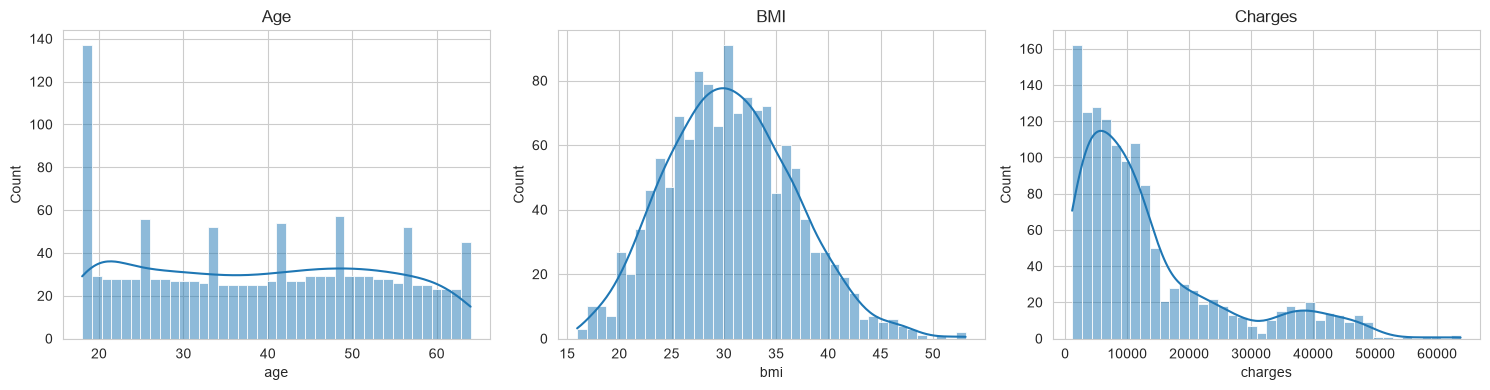

In [ ]:
# TODO
for col in ['age', 'bmi', 'charges']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,3,figsize=(15,4))
sns.histplot(df['age'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('Age')
sns.histplot(df['bmi'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('BMI')
sns.histplot(df['charges'],bins=40,kde=True,ax=axes[2]); axes[2].set_title('Charges')
plt.tight_layout(); plt.show()


Nhận xét:
- bmi: Phân phối đối xứng hình quả chuông, rất gần với phân phối chuẩn.
- age: Phân bố tương đối đều, chỉ nhô cao đột biến ở nhóm khách hàng trẻ (18-19 tuổi).
- charges: Lệch phải rất mạnh. Đa số đóng phí thấp, nhưng có một số ít người phải chịu chi phí y tế cực kỳ cao, tạo ra các outliers kéo dài ở đuôi phải.

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

- Chi phí trung bình của người hút thuốc: 32,050 USD
- Chi phí trung bình của người KHÔNG hút: 8,434 USD
=> Người hút thuốc phải trả chi phí cao gấp 3.8 lần so với người không hút.


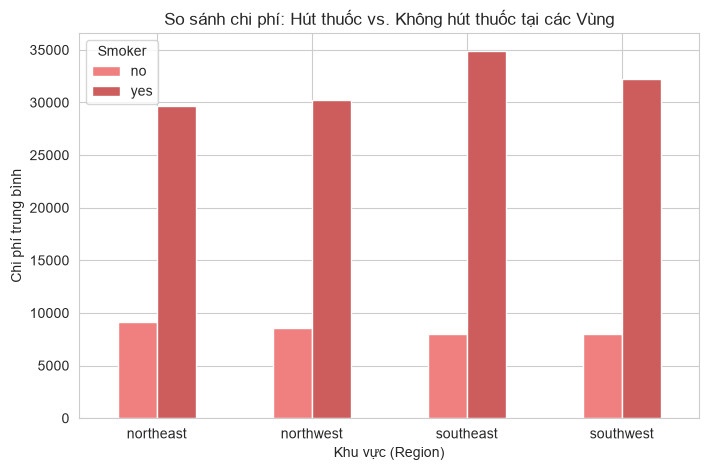

In [24]:
# TODO
chi_phi_thuoc = df.groupby('smoker')['charges'].mean()
phi_yes = chi_phi_thuoc['yes']
phi_no = chi_phi_thuoc['no']
so_lan = phi_yes / phi_no

print(f"- Chi phí trung bình của người hút thuốc: {phi_yes:,.0f} USD")
print(f"- Chi phí trung bình của người KHÔNG hút: {phi_no:,.0f} USD")
print(f"=> Người hút thuốc phải trả chi phí cao gấp {so_lan:.1f} lần so với người không hút.")

chi_phi_vung = df.groupby(['region', 'smoker'])['charges'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
chi_phi_vung.plot(kind='bar', ax=ax, color=['lightcoral', 'indianred'])
ax.set_title('So sánh chi phí: Hút thuốc vs. Không hút thuốc tại các Vùng')
ax.set_ylabel('Chi phí trung bình')
ax.set_xlabel('Khu vực (Region)')
plt.xticks(rotation=0)
plt.legend(title='Smoker')
plt.show()

Insight: Việc hút thuốc là nguyên nhân chính làm chi phí y tế tăng đột biến (gấp 3.8 lần). Sự chênh lệch khổng lồ này diễn ra đồng đều ở tất cả 4 khu vực, chứng tỏ thói quen hút thuốc tác động đến chi phí bảo hiểm mạnh mẽ và rõ rệt hơn hẳn so với yếu tố vị trí địa lý.

## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

- Hệ số tương quan BMI & Chi phí (Nhóm hút thuốc): 0.81
- Hệ số tương quan BMI & Chi phí (Nhóm không hút): 0.08
=> Hệ số càng gần 1 thì mức độ tỷ lệ thuận càng mạnh.


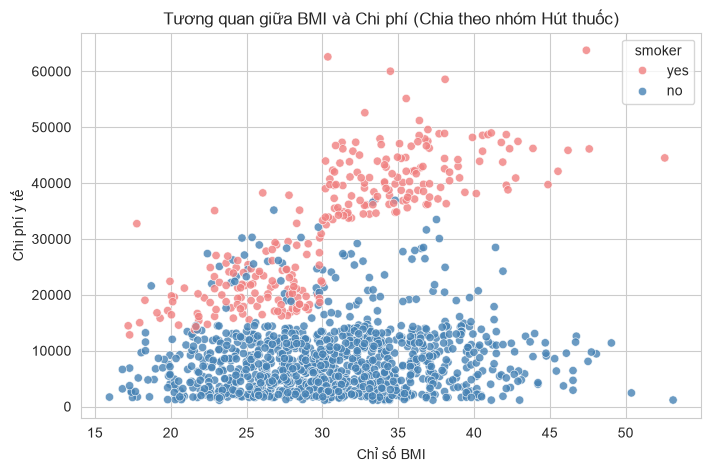

In [27]:
# TODO
nhom_hut_thuoc = df[df['smoker'] == 'yes']
nhom_khong_hut = df[df['smoker'] == 'no']

corr_yes = nhom_hut_thuoc['bmi'].corr(nhom_hut_thuoc['charges'])
corr_no = nhom_khong_hut['bmi'].corr(nhom_khong_hut['charges'])

print(f"- Hệ số tương quan BMI & Chi phí (Nhóm hút thuốc): {corr_yes:.2f}")
print(f"- Hệ số tương quan BMI & Chi phí (Nhóm không hút): {corr_no:.2f}")
print("=> Hệ số càng gần 1 thì mức độ tỷ lệ thuận càng mạnh.")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette=['lightcoral', 'steelblue'], alpha=0.8, ax=ax)
ax.set_title('Tương quan giữa BMI và Chi phí (Chia theo nhóm Hút thuốc)')
ax.set_xlabel('Chỉ số BMI')
ax.set_ylabel('Chi phí y tế')
plt.show()

nsight: BMI có tính tương quan thuận cực kỳ mạnh mẽ với chi phí y tế ở nhóm người hút thuốc, trong khi ở nhóm không hút thuốc thì BMI gần như không ảnh hưởng. Điều này cho thấy nếu một người vừa béo phì (BMI cao) vừa hút thuốc, rủi ro sức khỏe sẽ bị cộng gộp nghiêm trọng, dẫn đến chi phí bảo hiểm tăng vọt.

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [36]:
# TODO
region_charges = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print("Chi phí trung bình theo vùng:")
print(region_charges.round(0))

Chi phí trung bình theo vùng:
region
southeast    14735.0
northeast    13406.0
northwest    12418.0
southwest    12347.0
Name: charges, dtype: float64


Insight: Vùng Đông Nam (southeast) có chi phí bảo hiểm trung bình cao nhất, đạt khoảng 14,735 USD. Sự chênh lệch này gợi ý rằng cư dân ở khu vực Đông Nam có thể có tỷ lệ mắc các rủi ro sức khỏe cao hơn (như béo phì hoặc hút thuốc) so với các vùng khác.

## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?


Chi phí trung bình theo số lượng con:
children
0    12366.0
1    12731.0
2    15074.0
3    15355.0
4    13851.0
5     8786.0
Name: charges, dtype: float64


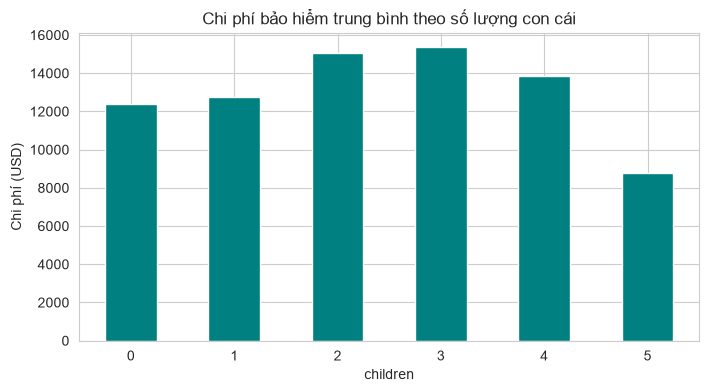

In [33]:
# TODO
charges_by_children = df.groupby('children')['charges'].mean()
print("\nChi phí trung bình theo số lượng con:")
print(charges_by_children.round(0))

fig, ax = plt.subplots(figsize=(8, 4))
charges_by_children.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Chi phí bảo hiểm trung bình theo số lượng con cái')
ax.set_ylabel('Chi phí (USD)')
plt.xticks(rotation=0)
plt.show()

Insight: Chi phí trung bình có xu hướng tăng nhẹ từ nhóm có 0 đến 3 đứa con, nhưng lại giảm mạnh ở nhóm có 4-5 con. Điều này cho thấy số lượng con cái không phải là yếu tố chính làm tăng chi phí y tế một cách tuyến tính và rõ rệt.

## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Hệ số tương quan giữa tuổi và chi phí: 0.30


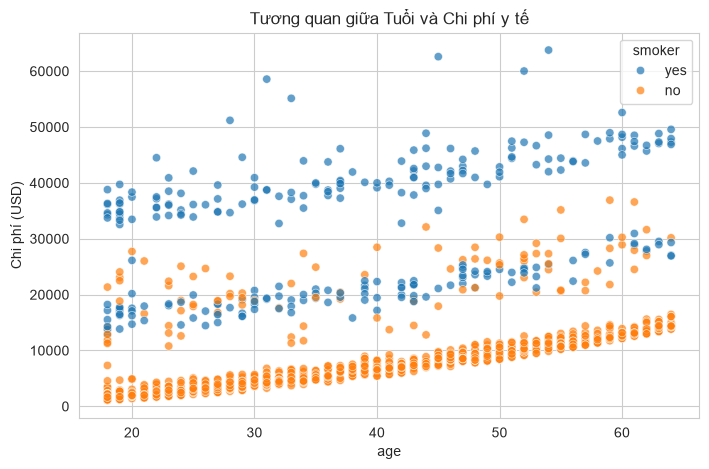

In [38]:
# TODO
corr_age=df['age'].corr(df['charges'])
print(f"Hệ số tương quan giữa tuổi và chi phí: {corr_age:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
ax.set_title('Tương quan giữa Tuổi và Chi phí y tế')
ax.set_ylabel('Chi phí (USD)')
plt.show()

Insight: Có sự tương quan thuận giữa độ tuổi và chi phí (tuổi càng cao, phí càng tăng). Nhìn vào biểu đồ phân tán, chi phí tăng dần đều theo độ tuổi tạo thành 3 dải đường chéo song song đi lên, phản ánh quy luật lão hóa tự nhiên: tuổi cao kéo theo rủi ro bệnh lý tăng, khiến phí bảo hiểm cũng tịnh tiến theo.

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Phân tích dữ liệu bảo hiểm y tế cho thấy thói quen hút thuốc là yếu tố có sức tàn phá lớn nhất đến tài chính, đẩy chi phí lên gấp gần 4 lần so với bình thường. Yếu tố này còn trở nên nguy hiểm hơn khi kết hợp với tình trạng béo phì (BMI cao), tạo ra một nhóm khách hàng mang rủi ro cực kỳ lớn. Về mặt sinh học, độ tuổi cũng tỷ lệ thuận với chi phí y tế một cách đều đặn, phản ánh sự suy giảm sức khỏe tự nhiên theo thời gian. Trong khi đó, các yếu tố về nhân khẩu học như khu vực sống hay số lượng con cái lại ít có tác động rõ rệt. Tóm lại, chân dung một khách hàng phải đóng mức phí bảo hiểm y tế cao nhất là: Người lớn tuổi, mắc bệnh béo phì và có thói quen hút thuốc lá.